Radius: 5.0 ± 0.50

Area (A = πr²):
  Mean: 79.30 cm²
  Std: 15.80 cm²
  95% CI: [50.66, 112.61] cm²

Circumference (C = 2πr):
  Mean: 31.41 cm
  Std: 3.15 cm
  95% CI: [25.23, 37.62] cm


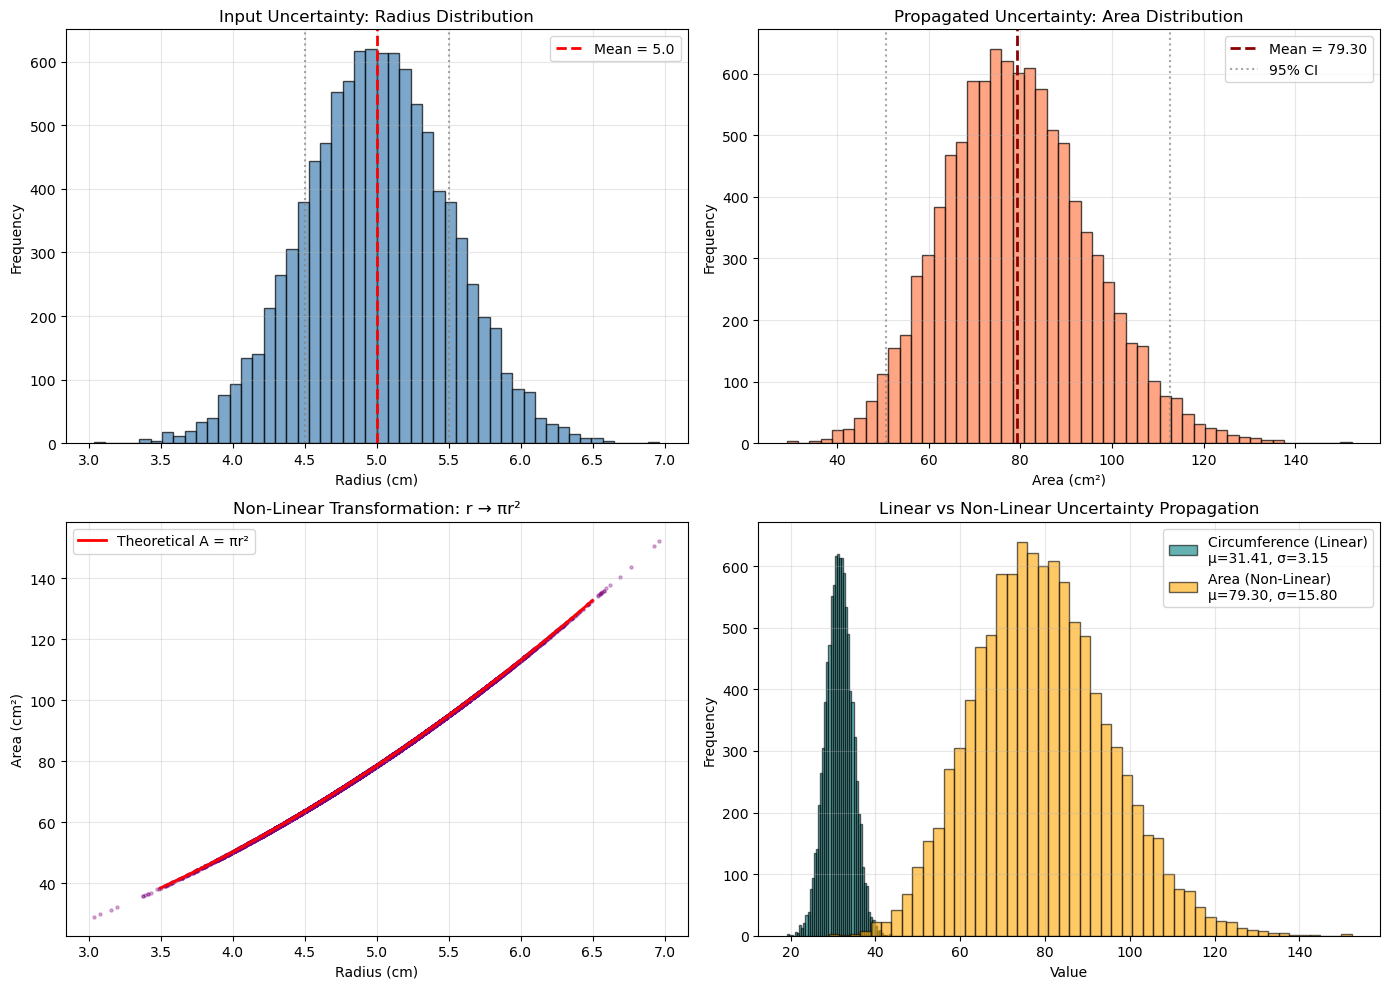


Chart saved as 'uncertainty_propagation.png'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Define the Problem ---
# Example: We measure a circle's radius with uncertainty
# r = 5.0 ± 0.5 cm (Gaussian uncertainty)
r_mean = 5.0
r_std = 0.5
n_samples = 10000

# --- 2. Monte Carlo Sampling ---
# Sample from the input distribution
r_samples = np.random.normal(r_mean, r_std, n_samples)

# Apply the non-linear function: Area = π * r²
A_samples = np.pi * r_samples**2

# Also calculate circumference for comparison: C = 2πr
C_samples = 2 * np.pi * r_samples

# --- 3. Statistics ---
A_mean = np.mean(A_samples)
A_std = np.std(A_samples)
A_ci_95 = np.percentile(A_samples, [2.5, 97.5])

C_mean = np.mean(C_samples)
C_std = np.std(C_samples)
C_ci_95 = np.percentile(C_samples, [2.5, 97.5])

print(f"Radius: {r_mean} ± {r_std:.2f}")
print(f"\nArea (A = πr²):")
print(f"  Mean: {A_mean:.2f} cm²")
print(f"  Std: {A_std:.2f} cm²")
print(f"  95% CI: [{A_ci_95[0]:.2f}, {A_ci_95[1]:.2f}] cm²")
print(f"\nCircumference (C = 2πr):")
print(f"  Mean: {C_mean:.2f} cm")
print(f"  Std: {C_std:.2f} cm")
print(f"  95% CI: [{C_ci_95[0]:.2f}, {C_ci_95[1]:.2f}] cm")

# --- 4. Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Input Distribution (Radius)
axes[0, 0].hist(r_samples, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(r_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {r_mean}')
axes[0, 0].axvline(r_mean - r_std, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].axvline(r_mean + r_std, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].set_xlabel('Radius (cm)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Input Uncertainty: Radius Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Output Distribution (Area)
axes[0, 1].hist(A_samples, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(A_mean, color='darkred', linestyle='--', linewidth=2, label=f'Mean = {A_mean:.2f}')
axes[0, 1].axvline(A_ci_95[0], color='gray', linestyle=':', alpha=0.7, label='95% CI')
axes[0, 1].axvline(A_ci_95[1], color='gray', linestyle=':', alpha=0.7)
axes[0, 1].set_xlabel('Area (cm²)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Propagated Uncertainty: Area Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter of Radius vs Area (showing non-linearity)
axes[1, 0].scatter(r_samples, A_samples, alpha=0.3, s=5, color='purple')
axes[1, 0].set_xlabel('Radius (cm)')
axes[1, 0].set_ylabel('Area (cm²)')
axes[1, 0].set_title('Non-Linear Transformation: r → πr²')
axes[1, 0].grid(True, alpha=0.3)

# Add the theoretical curve
r_theory = np.linspace(r_mean - 3*r_std, r_mean + 3*r_std, 100)
axes[1, 0].plot(r_theory, np.pi * r_theory**2, 'r-', linewidth=2, label='Theoretical A = πr²')
axes[1, 0].legend()

# Plot 4: Comparison of Linear vs Non-Linear Propagation
# Circumference is linear (C = 2πr), Area is non-linear (A = πr²)
axes[1, 1].hist(C_samples, bins=50, color='teal', alpha=0.6, edgecolor='black', 
                label=f'Circumference (Linear)\nμ={C_mean:.2f}, σ={C_std:.2f}')
axes[1, 1].hist(A_samples, bins=50, color='orange', alpha=0.6, edgecolor='black', 
                label=f'Area (Non-Linear)\nμ={A_mean:.2f}, σ={A_std:.2f}')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Linear vs Non-Linear Uncertainty Propagation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('uncertainty_propagation.png', dpi=150)
plt.show()

print("\nChart saved as 'uncertainty_propagation.png'")